In [1]:
import pandas as pd
import json
import os
import random


PATH_TO_CONSTANTS = "../"

with open(PATH_TO_CONSTANTS+'constants.json') as f:
    CONSTANTS = json.load(f)

In [2]:

DIR_TO_DATASET = PATH_TO_CONSTANTS + CONSTANTS['llm_outs'] +"/DATASET"


dataset_files = [x for x in os.listdir(DIR_TO_DATASET) if ('jsonl' in x) and ('cleaned_dataset' not in x) ]

In [3]:
dataset_files

['060000_090000.jsonl',
 '030000_060000.jsonl',
 '000000_030000.jsonl',
 '090000_120000.jsonl',
 '150000_180000.jsonl',
 '180000_210000.jsonl',
 '120000_150000.jsonl',
 '240000_269574.jsonl',
 '210000_240000.jsonl']

In [4]:

# Dictionary to store parsed data
full_ds = []

# Load all JSON files into the dictionary
for file in sorted(dataset_files):
    print(file)
    file_path = os.path.join(DIR_TO_DATASET, file)
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line.strip())  # Parse each JSON object
            full_ds.append(record)  # A


000000_030000.jsonl
030000_060000.jsonl
060000_090000.jsonl
090000_120000.jsonl
120000_150000.jsonl
150000_180000.jsonl
180000_210000.jsonl
210000_240000.jsonl
240000_269574.jsonl


In [6]:
len(full_ds)

269574

In [5]:
import re

# parsed_data ={}
num_erros = 0

for i  in range(len(full_ds)):

    matches = re.findall(r"\{.*?\}", full_ds[i]['text'], re.DOTALL)

    if matches:
        last_json_str = matches[-1]  # Get the last JSON block
        try:
            parsed_json = json.loads(last_json_str, strict = False)  # Parse JSON
            if 'question' not in parsed_json or 'answer' not in parsed_json:
                print(full_ds[i]['id'], parsed_json.keys())
                full_ds[i]['json_parsed'] = False
                num_erros+=1

                # parsed_data[k] = "ERROR"

            else:
                full_ds[i].update(parsed_json)
                full_ds[i]['json_parsed'] = True
        except json.JSONDecodeError as e:
            print(full_ds[i]['id'],e)
            full_ds[i]['json_parsed'] = False
            num_erros+=1
            # parsed_data[k] = "ERROR"
            
    else:
        print(full_ds[i]['id']," No JSON found in the output.")
        full_ds[i]['json_parsed'] = False
        num_erros+=1

        
    #230 
    
    
    # 445 truncated
    # 551 truncated
    
    

642 Unterminated string starting at: line 3 column 13 (char 272)
1170 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1929 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
2500 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
2635 Unterminated string starting at: line 3 column 13 (char 270)
2998 Unterminated string starting at: line 3 column 13 (char 284)
3037 Unterminated string starting at: line 3 column 13 (char 329)
3047  No JSON found in the output.
3694  No JSON found in the output.
4026 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
4760 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
4800 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
4941 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
6036 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
7457 Expecting prop

In [15]:
num_erros

543

In [16]:
filtered_ds = [i for i in full_ds if i['json_parsed'] == True]


In [17]:
len(full_ds), len(filtered_ds)

(269574, 269031)

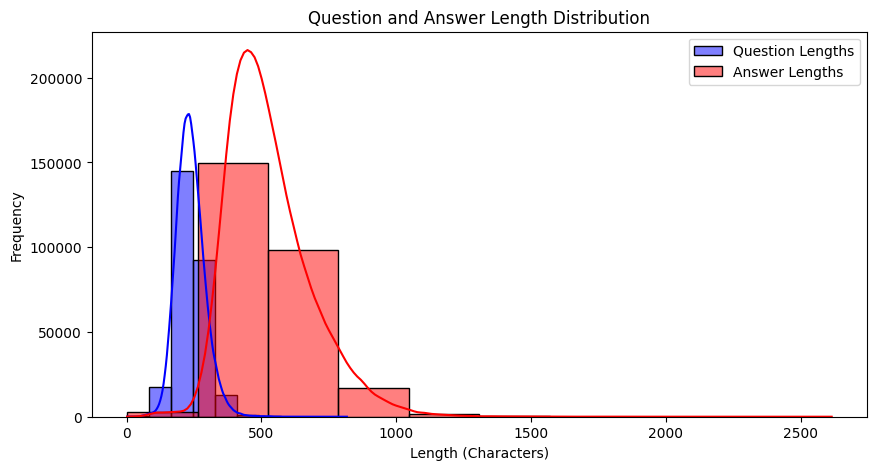

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
# Extract lengths
question_lengths = [len(item["question"]) for item in filtered_ds]
answer_lengths = [len(item["answer"]) for item in filtered_ds]

# Plot distributions
plt.figure(figsize=(10, 5))
sns.histplot(question_lengths, bins=10, kde=True, color='blue', label='Question Lengths')
sns.histplot(answer_lengths, bins=10, kde=True, color='red', label='Answer Lengths')
plt.xlabel("Length (Characters)")
plt.ylabel("Frequency")
plt.title("Question and Answer Length Distribution")
plt.legend()
plt.show()


In [21]:
import numpy as np

def get_outlier_ranges(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    z_threshold = 3  # Standard threshold for outliers

    lower_bound = mean - z_threshold * std_dev
    upper_bound = mean + z_threshold * std_dev

    # Count outliers
    outlier_count = sum(1 for x in data if x < lower_bound or x > upper_bound)

    return {
        "range": (lower_bound, upper_bound),
        "Number of Outliers": outlier_count
    }



answer_outliers = get_outlier_ranges(answer_lengths)
print(answer_outliers)

question_outliers = get_outlier_ranges(question_lengths)

print(question_outliers)


{'range': (58.49223189277507, 996.5025753970912), 'Number of Outliers': 2687}
{'range': (78.02531583366459, 395.89086482953036), 'Number of Outliers': 2110}


In [22]:
reduced_ds = [i for i in filtered_ds if len(i['answer'])>answer_outliers['range'][0] and len(i['answer'])< answer_outliers['range'][1]
                                            and len(i['question'])>question_outliers['range'][0] and len(i['question'])<question_outliers['range'][1]]

In [23]:
len(full_ds),len(filtered_ds),len(reduced_ds)

(269574, 269031, 264373)

In [1]:
269031 - 264373

4658

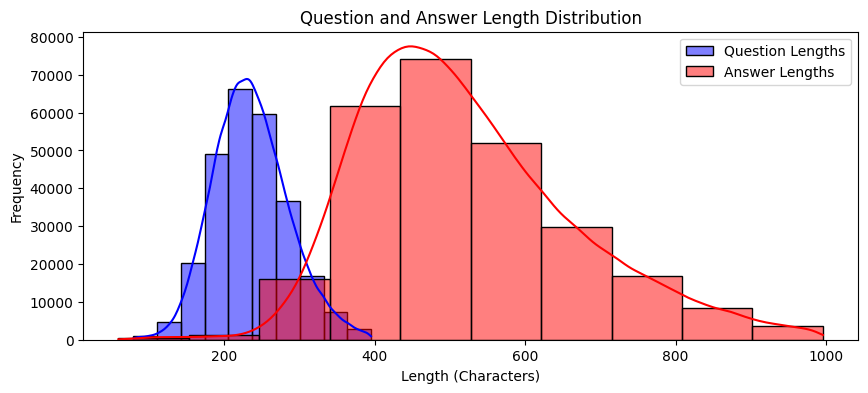

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
# Extract lengths
question_lengths = [len(item["question"]) for item in reduced_ds]
answer_lengths = [len(item["answer"]) for item in reduced_ds]

# Plot distributions
plt.figure(figsize=(10, 4))
sns.histplot(question_lengths, bins=10, kde=True, color='blue', label='Question Lengths')
sns.histplot(answer_lengths, bins=10, kde=True, color='red', label='Answer Lengths')
plt.xlabel("Length (Characters)")
plt.ylabel("Frequency")
plt.title("Question and Answer Length Distribution")
plt.legend()
plt.show()


In [25]:
with open(PATH_TO_CONSTANTS + CONSTANTS['llm_outs'] +"/DATASET/cleaned_dataset.jsonl", 'w') as fp:
    for item in reduced_ds:
        fp.write(json.dumps(item) + "\n")